# t-SNE / UMAP — A1 Backbone Feature Visualisation

**Purpose (Task A1.11):** Visualise the 2048-d backbone features learned by the OrdSupCon pipeline
to verify that ordinal DR-grade structure was encoded in the representation space.

**Checkpoint note:** `run_contrastive_pretraining()` now saves a dedicated
`{exp_name}_backbone.pth` to the checkpoints folder (backbone only, projector discarded).
The notebook prefers that file; if it is absent it falls back to the Stage 2 fine-tuned
checkpoint (`exp103_a1_ordsupcon_aptos_best.pth`) and strips the FC head via `nn.Identity()`.
Both routes produce identical 2048-d backbone features.

**Pipeline:**
1. Load Stage 2 checkpoint → strip FC head → feature extractor
2. Extract 2048-d features for the full APTOS training set (no augmentation)
3. PCA → 50-d pre-reduction (speeds up t-SNE/UMAP)
4. t-SNE (2-d) — good local structure
5. UMAP (2-d) — good global + local structure
6. Side-by-side comparison vs ImageNet baseline (no contrastive training)
7. Quantitative ordinal distance check in PCA space

---
**What to look for:**
- Grades should form an **ordinal gradient** (0 → 1 → 2 → 3 → 4) across the plot
- Grade 3 and 4 should be clearly **separated from Grade 0**
- Adjacent grades (e.g. 1 vs 2) may overlap — that is clinically expected
- Compare against ImageNet baseline to confirm contrastive training added structure

## 0 — Setup & Paths

In [3]:
import gc
import torch

# Delete large variables you no longer need
# del feats_contra, feats_imgnet  # raw 2048-d arrays (largest)

gc.collect()
torch.cuda.empty_cache()

In [4]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tvm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# ── project root ─────────────────────────────────────────────────────────────
ROOT_DIR = Path(".").resolve().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.dataset import DRDataset, load_labels
from src.config import TRAIN_CSV, TRAIN_IMG_DIR, IMAGENET_MEAN, IMAGENET_STD, IMAGE_SIZE
from src.models import GeM

# ── Checkpoints ───────────────────────────────────────────────────────────────
EXP_NAME  = "exp103_a1_ordsupcon_aptos"
CKPT_DIR  = ROOT_DIR / "checkpoints" / EXP_NAME

# Preferred: backbone-only checkpoint saved by run_contrastive_pretraining()
BACKBONE_CKPT = CKPT_DIR / f"{EXP_NAME}_backbone.pth"
# Fallback: Stage 2 fine-tuned model (backbone weights are identical inside)
STAGE2_CKPT   = CKPT_DIR / f"{EXP_NAME}_best.pth"

# ── Output ────────────────────────────────────────────────────────────────────
RESULTS_DIR = ROOT_DIR / "results" / EXP_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Misc ──────────────────────────────────────────────────────────────────────
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE       = 128
NUM_WORKERS      = 0
PCA_COMPONENTS   = 50    # pre-reduce before t-SNE / UMAP
TSNE_PERPLEXITY  = 40
UMAP_N_NEIGHBORS = 30

CLASS_NAMES  = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
CLASS_COLORS = ["#4CAF50", "#8BC34A", "#FFC107", "#FF5722", "#F44336"]

print(f"Device        : {DEVICE}")
if BACKBONE_CKPT.exists():
    print(f"Backbone ckpt : {BACKBONE_CKPT.name}  ✅ (preferred)")
elif STAGE2_CKPT.exists():
    print(f"Backbone ckpt : NOT FOUND — falling back to Stage 2 checkpoint")
    print(f"Stage 2 ckpt  : {STAGE2_CKPT.name}  ✅")
else:
    print("ERROR: neither backbone nor Stage 2 checkpoint found — check CKPT_DIR")


Device        : cuda
Backbone ckpt : NOT FOUND — falling back to Stage 2 checkpoint
Stage 2 ckpt  : exp103_a1_ordsupcon_aptos_best.pth  ✅


## 1 — Build Feature Extractor

- **If `{exp_name}_backbone.pth` exists** (saved by `run_contrastive_pretraining()`): load directly — it is already a bare backbone with no FC head.
- **Fallback — Stage 2 checkpoint**: full model (`backbone + fc: Linear(2048, 5)`); we replace `fc` with `nn.Identity()` to recover 2048-d features. The backbone weights are the same in both cases.

In [5]:
def _load_state_dict(ckpt_path: Path) -> dict:
    """Load a state_dict, unwrapping common checkpoint wrappers."""
    sd = torch.load(ckpt_path, map_location="cpu")
    if isinstance(sd, dict):
        for key in ("model_state_dict", "state_dict"):
            if key in sd:
                sd = sd[key]
                break
    # Strip DataParallel 'module.' prefix if present
    if any(k.startswith("module.") for k in sd):
        sd = {k[len("module."):]: v for k, v in sd.items()}
    return sd


def build_feature_extractor(
    backbone_ckpt: Path, stage2_ckpt: Path, device: torch.device
) -> nn.Module:
    """Load the contrastive backbone.  Prefers backbone_ckpt; falls back to stage2_ckpt."""
    model = tvm.resnet50(weights=None)
    model.avgpool = GeM(p=3.0)

    if backbone_ckpt.exists():
        # Backbone-only checkpoint: no FC key present — load with fc=Identity directly
        model.fc = nn.Identity()
        model.load_state_dict(_load_state_dict(backbone_ckpt), strict=True)
        print(f"Loaded backbone checkpoint : {backbone_ckpt.name}")
    else:
        # Stage 2 checkpoint: has fc weights — load with fc=Linear, then swap to Identity
        model.fc = nn.Linear(2048, 5)
        model.load_state_dict(_load_state_dict(stage2_ckpt), strict=True)
        model.fc = nn.Identity()
        print(f"Backbone ckpt not found — loaded Stage 2 checkpoint : {stage2_ckpt.name}")
        print("(fc head stripped via nn.Identity — backbone weights are identical)")

    model.eval()
    return model.to(device)


def build_imagenet_baseline(device: torch.device) -> nn.Module:
    """Plain ImageNet-pretrained ResNet-50+GeM — no contrastive training."""
    model = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
    model.avgpool = GeM(p=3.0)
    model.fc = nn.Identity()
    model.eval()
    return model.to(device)


extractor_contrastive = build_feature_extractor(BACKBONE_CKPT, STAGE2_CKPT, DEVICE)
extractor_imagenet    = build_imagenet_baseline(DEVICE)
print(f"\nFeature dim : 2048")
print("Both extractors ready.")


Backbone ckpt not found — loaded Stage 2 checkpoint : exp103_a1_ordsupcon_aptos_best.pth
(fc head stripped via nn.Identity — backbone weights are identical)

Feature dim : 2048
Both extractors ready.


## 2 — Load APTOS Training Set (no augmentation)

In [6]:
labels = load_labels(TRAIN_CSV)
id_codes = list(labels.keys())

# DRDataset with transform=None → only ben_graham_preprocess + ImageNet normalisation
dataset = DRDataset(
    id_codes=id_codes,
    labels=labels,
    img_dir=TRAIN_IMG_DIR,
    transform=None,   # no augmentation — deterministic, reproducible
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"Dataset size : {len(dataset):,} images")
print(f"Batches      : {len(loader)}")

# Class distribution sanity check
from collections import Counter
dist = Counter(labels[c] for c in id_codes)
for cls, name in enumerate(CLASS_NAMES):
    print(f"  [{cls}] {name:<18} {dist[cls]:>5,}")

Dataset size : 3,112 images
Batches      : 25
  [0] No DR              1,534
  [1] Mild                 314
  [2] Moderate             849
  [3] Severe               164
  [4] Proliferative        251


## 3 — Feature Extraction

In [7]:
@torch.no_grad()
def extract_features(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    desc: str = "Extracting",
) -> tuple[np.ndarray, np.ndarray]:
    """Return (features [N, 2048], labels [N]) as numpy arrays."""
    all_feats, all_labels = [], []
    for imgs, targets, _ in tqdm(loader, desc=desc):
        imgs = imgs.to(device)
        feats = model(imgs)                    # [B, 2048]
        all_feats.append(feats.cpu().float().numpy())
        all_labels.append(targets.numpy())
    feats_np  = np.concatenate(all_feats,  axis=0)   # [N, 2048]
    labels_np = np.concatenate(all_labels, axis=0)   # [N]
    print(f"  → features shape : {feats_np.shape}")
    return feats_np, labels_np


print("Extracting contrastive backbone features...")
feats_contra, labels_np = extract_features(extractor_contrastive, loader, DEVICE, "Contrastive backbone")

print("\nExtracting ImageNet baseline features...")
feats_imgnet, _         = extract_features(extractor_imagenet,    loader, DEVICE, "ImageNet baseline")

Extracting contrastive backbone features...


Contrastive backbone:   0%|          | 0/25 [00:00<?, ?it/s]

  → features shape : (3112, 2048)

Extracting ImageNet baseline features...


ImageNet baseline:   0%|          | 0/25 [00:00<?, ?it/s]

  → features shape : (3112, 2048)


## 4 — PCA Pre-reduction (2048 → 50)

t-SNE and UMAP on 2048-d directly is very slow and degrades quality.
PCA to 50-d is the standard pre-step (Barnes-Hut t-SNE paper recommendation).

In [ ]:
del feats_contra, feats_imgnet  # raw 2048-d arrays (largest)

In [8]:
pca_contra = PCA(n_components=PCA_COMPONENTS, random_state=42)
pca_imgnet = PCA(n_components=PCA_COMPONENTS, random_state=42)

feats_contra_pca = pca_contra.fit_transform(feats_contra)
feats_imgnet_pca = pca_imgnet.fit_transform(feats_imgnet)

var_contra = pca_contra.explained_variance_ratio_.sum() * 100
var_imgnet = pca_imgnet.explained_variance_ratio_.sum() * 100

print(f"Contrastive PCA  : {PCA_COMPONENTS}-d explains {var_contra:.1f}% of variance")
print(f"ImageNet PCA     : {PCA_COMPONENTS}-d explains {var_imgnet:.1f}% of variance")

Contrastive PCA  : 50-d explains 76.5% of variance
ImageNet PCA     : 50-d explains 61.9% of variance


## 5 — t-SNE

In [11]:
print("Running t-SNE (contrastive backbone)...")
tsne_contra = TSNE(
    n_components=2, perplexity=TSNE_PERPLEXITY,
    max_iter=1000, random_state=42, verbose=1,
)
feats_contra_tsne = tsne_contra.fit_transform(feats_contra_pca)

print("\nRunning t-SNE (ImageNet baseline)...")
tsne_imgnet = TSNE(
    n_components=2, perplexity=TSNE_PERPLEXITY,
    max_iter=1000, random_state=42, verbose=1,
)
feats_imgnet_tsne = tsne_imgnet.fit_transform(feats_imgnet_pca)
print("\nt-SNE done.")

Running t-SNE (contrastive backbone)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3112 samples in 0.001s...
[t-SNE] Computed neighbors for 3112 samples in 0.153s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3112
[t-SNE] Computed conditional probabilities for sample 2000 / 3112
[t-SNE] Computed conditional probabilities for sample 3000 / 3112
[t-SNE] Computed conditional probabilities for sample 3112 / 3112
[t-SNE] Mean sigma: 5.386523
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.687531
[t-SNE] KL divergence after 1000 iterations: 1.268376

Running t-SNE (ImageNet baseline)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3112 samples in 0.000s...
[t-SNE] Computed neighbors for 3112 samples in 0.068s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3112
[t-SNE] Computed conditional probabilities for sample 2000 / 3112
[t-SNE] Computed conditional probabilities for sample 3000 / 3112
[t-SNE] Compute

## 6 — UMAP

> If `umap-learn` is not installed: `pip install umap-learn`

In [12]:
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("umap-learn not installed — skipping UMAP. Run: pip install umap-learn")

if UMAP_AVAILABLE:
    print("Running UMAP (contrastive backbone)...")
    reducer_contra = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS, min_dist=0.1,
        metric="cosine", random_state=42, verbose=True,
    )
    feats_contra_umap = reducer_contra.fit_transform(feats_contra_pca)

    print("\nRunning UMAP (ImageNet baseline)...")
    reducer_imgnet = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS, min_dist=0.1,
        metric="cosine", random_state=42, verbose=True,
    )
    feats_imgnet_umap = reducer_imgnet.fit_transform(feats_imgnet_pca)
    print("\nUMAP done.")

Running UMAP (contrastive backbone)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr 14 12:25:13 2026 Construct fuzzy simplicial set
Tue Apr 14 12:25:20 2026 Finding Nearest Neighbors
Tue Apr 14 12:25:25 2026 Finished Nearest Neighbor Search
Tue Apr 14 12:25:28 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Apr 14 12:25:33 2026 Finished embedding

Running UMAP (ImageNet baseline)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr 14 12:25:33 2026 Construct fuzzy simplicial set
Tue Apr 14 12:25:40 2026 Finding Nearest Neighbors
Tue Apr 14 12:25:41 2026 Finished Nearest Neighbor Search
Tue Apr 14 12:25:41 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Apr 14 12:25:48 2026 Finished embedding

UMAP done.


## 7 — Plot: Contrastive vs ImageNet (t-SNE)

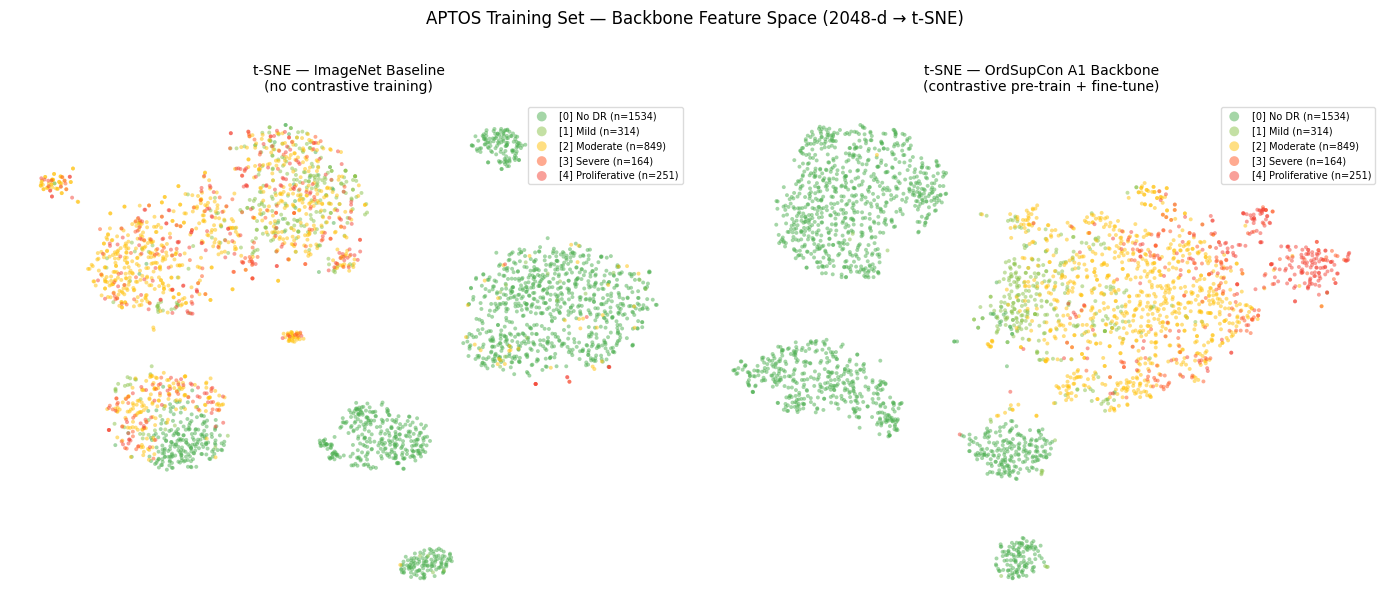

Saved: /workspace/dr-nrt/results/exp103_a1_ordsupcon_aptos/exp103_a1_tsne_comparison.png


In [13]:
def scatter_2d(
    ax: plt.Axes,
    feats_2d: np.ndarray,
    labels: np.ndarray,
    title: str,
) -> None:
    for cls in range(5):
        mask = labels == cls
        ax.scatter(
            feats_2d[mask, 0], feats_2d[mask, 1],
            c=CLASS_COLORS[cls],
            label=f"[{cls}] {CLASS_NAMES[cls]} (n={mask.sum()})",
            s=8, alpha=0.5, edgecolors="none",
        )
    ax.set_title(title, fontsize=10, pad=8)
    ax.axis("off")
    ax.legend(markerscale=2.5, fontsize=7, loc="best", framealpha=0.7)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_2d(axes[0], feats_imgnet_tsne, labels_np,
           "t-SNE — ImageNet Baseline\n(no contrastive training)")
scatter_2d(axes[1], feats_contra_tsne, labels_np,
           "t-SNE — OrdSupCon A1 Backbone\n(contrastive pre-train + fine-tune)")

fig.suptitle(
    "APTOS Training Set — Backbone Feature Space (2048-d → t-SNE)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
save_path = RESULTS_DIR / "exp103_a1_tsne_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 8 — Plot: Contrastive vs ImageNet (UMAP)

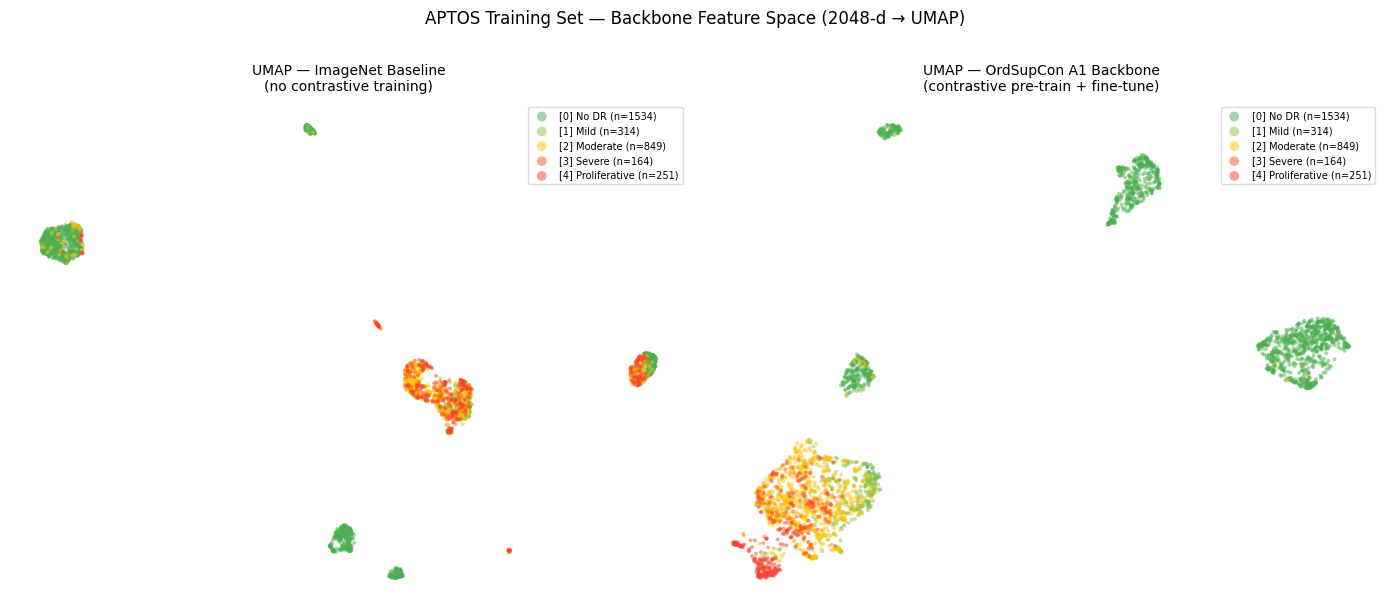

Saved: /workspace/dr-nrt/results/exp103_a1_ordsupcon_aptos/exp103_a1_umap_comparison.png


In [14]:
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    scatter_2d(axes[0], feats_imgnet_umap, labels_np,
               "UMAP — ImageNet Baseline\n(no contrastive training)")
    scatter_2d(axes[1], feats_contra_umap, labels_np,
               "UMAP — OrdSupCon A1 Backbone\n(contrastive pre-train + fine-tune)")

    fig.suptitle(
        "APTOS Training Set — Backbone Feature Space (2048-d → UMAP)",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    save_path = RESULTS_DIR / "exp103_a1_umap_comparison.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("UMAP not available — skipped.")

## 9 — 2×2 grid: t-SNE and UMAP together

In [ ]:
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    scatter_2d(axes[0][0], feats_imgnet_tsne, labels_np, "t-SNE — ImageNet Baseline")
    scatter_2d(axes[0][1], feats_contra_tsne, labels_np, "t-SNE — OrdSupCon A1")
    scatter_2d(axes[1][0], feats_imgnet_umap, labels_np, "UMAP — ImageNet Baseline")
    scatter_2d(axes[1][1], feats_contra_umap, labels_np, "UMAP — OrdSupCon A1")

    # Row labels
    for i, row_label in enumerate(["t-SNE", "UMAP"]):
        axes[i][0].set_ylabel(row_label, fontsize=11, labelpad=10)

    fig.suptitle(
        "APTOS Backbone Feature Space — ImageNet vs OrdSupCon A1",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    save_path = RESULTS_DIR / "exp103_a1_feature_space_grid.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

## 10 — Quantitative: Mean Pairwise L2 Distance Between Classes

Verify that the **ordinal distance structure** is present in the feature space:
- `dist(0, 4)` should be the largest (most different classes)
- `dist(0, 1)` should be the smallest non-zero distance
- Distances should increase monotonically with `|grade_i - grade_j|`

We compare class **centroids** in the PCA-50 space.

In [ ]:
import pandas as pd
from itertools import combinations

def pairwise_centroid_distances(
    feats: np.ndarray, labels: np.ndarray, name: str
) -> pd.DataFrame:
    """Compute L2 distance between class centroids in the given feature space."""
    centroids = np.stack([
        feats[labels == cls].mean(axis=0) for cls in range(5)
    ])  # [5, D]

    rows = []
    for i, j in combinations(range(5), 2):
        dist = float(np.linalg.norm(centroids[i] - centroids[j]))
        rows.append({
            "pair": f"{CLASS_NAMES[i][:4]} ↔ {CLASS_NAMES[j][:4]}",
            "|Δgrade|": abs(i - j),
            f"dist ({name})": round(dist, 3),
        })

    df = pd.DataFrame(rows).sort_values("|Δgrade|").reset_index(drop=True)
    return df


df_contra = pairwise_centroid_distances(feats_contra_pca, labels_np, "contrastive")
df_imgnet = pairwise_centroid_distances(feats_imgnet_pca, labels_np, "imagenet")

df_merged = df_contra.merge(df_imgnet[["pair", "dist (imagenet)"]], on="pair")

print("Pairwise centroid L2 distances (PCA-50 space)")
print("Contrastive model should show larger distances for higher |Δgrade|\n")
print(df_merged.to_string(index=False))

In [ ]:
# Visualise: distance grouped by |Δgrade|
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, col, title, color in [
    (axes[0], "dist (imagenet)",    "ImageNet Baseline",    "steelblue"),
    (axes[1], "dist (contrastive)", "OrdSupCon A1",         "#FF5722"),
]:
    grouped = df_merged.groupby("|Δgrade|")[col].mean()
    bars = ax.bar(grouped.index, grouped.values, color=color, alpha=0.8, edgecolor="black", linewidth=0.6)
    for bar, val in zip(bars, grouped.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("|Grade difference|")
    ax.set_ylabel("Mean centroid L2 distance")
    ax.set_title(f"Inter-class distance by |Δgrade|\n{title}")
    ax.set_xticks([1, 2, 3, 4])

plt.suptitle("Ordinal structure check — distance should increase with |Δgrade|",
             fontsize=11, y=1.02)
plt.tight_layout()
save_path = RESULTS_DIR / "exp103_a1_ordinal_distances.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 11 — Summary

| Check | Expected (OrdSupCon) | Expected (ImageNet) |
|-------|---------------------|--------------------|
| t-SNE/UMAP ordinal gradient | Grades form a progression 0→1→2→3→4 | Mixed / no clear order |
| Grade 0 separated from Grade 4 | Large gap | Smaller gap |
| Distance monotonicity | dist grows with \|Δgrade\| | Irregular |
| Grade 3 visible cluster | Somewhat distinct despite n≈139 | Buried in noise |

In [ ]:
# Quick monotonicity check for the contrastive model
grouped_contra = df_merged.groupby("|Δgrade|")["dist (contrastive)"].mean()
diffs = grouped_contra.diff().dropna()
is_monotone = (diffs > 0).all()

print("Mean centroid distance by |Δgrade| (contrastive):")
for delta, val in grouped_contra.items():
    print(f"  |Δgrade| = {delta}  →  {val:.3f}")

print()
if is_monotone:
    print("✅  Distances are monotonically increasing with |Δgrade|.")
    print("    OrdSupCon successfully encoded ordinal DR-grade structure.")
else:
    print("⚠️  Distances are NOT monotone — ordinal structure incomplete.")
    print("    Consider: more contrastive epochs, higher τ, or Phase B (EyePACS).")